# Stage 3 — Threshold Stability Analysis

This notebook evaluates the stability and performance of the Stage 3 Neural LOD system, which predicts 4-value threshold vectors instead of a single global bias.

**Key Metrics**:
1. **Threshold Stability**: How often the predicted transition heights change (Flip Rate).
2. **Threshold Distribution**: Variance and range of predicted LOD transition heights.
3. **Performance**: Runtime overhead (CPU/GPU) compared to fixed-quality baselines.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sns.set_style('darkgrid')
print('Libraries loaded OK')

Libraries loaded OK


In [2]:
BASE_DIR = Path('../..').resolve()
EVAL_DIR = BASE_DIR / 'data' / 'Baker_Eval_3'
BASELINE_DIR = BASE_DIR / 'data' / 'BaseLine'
PLOTS_DIR = BASE_DIR / 'plots' / 'Stage_3' / 'Eval'
OBJECTS_FILE = BASE_DIR / 'data' / 'Baker_2' / 'lod_objects.csv'

PLOTS_DIR.mkdir(parents=True, exist_ok=True)

RUN_COLORS = {
    'neural_4thresh':     '#2196F3',
    'neural_baker_4val':  '#2196F3',
    'fixed_default':      '#4CAF50',
    'fixed_aggressive':   '#FF9800',
}
DEFAULT_COLOR = '#9C27B0'

FRAME_BUDGET_MS = 16.67 # 60 FPS

## 1. Load Evaluation Data

In [3]:
csv_files = list(EVAL_DIR.glob('inference_eval_*.csv')) + list(BASELINE_DIR.glob('inference_eval_*.csv'))
print(f'Found {len(csv_files)} evaluation files.')

dfs = []
for f in csv_files:
    df = pd.read_csv(f)
    df['source_file'] = f.name
    dfs.append(df)

if not dfs:
    raise FileNotFoundError("No evaluation files found.")

data = pd.concat(dfs, ignore_index=True)

# Ensure numeric columns for 4 thresholds
threshold_cols = ['predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3']
numeric_cols = ['frame', 'cpu_ms', 'gpu_ms', 'fps', 'inference_duration_ms', 'lod_bias_applied'] + threshold_cols
for col in numeric_cols:
    if col in data.columns:
        data[col] = pd.to_numeric(data[col], errors='coerce')

print(f'Loaded {len(data)} frames across {data[ "run_label" ].nunique()} runs.')
runs = sorted(data['run_label'].unique())
data.head()

Found 3 evaluation files.
Loaded 11916 frames across 3 runs.


,run_label,frame,cpu_ms,gpu_ms,fps,inference_duration_ms,predicted_t0,predicted_t1,predicted_t2,predicted_t3,...,cam_pos_z,cam_rot_x,cam_rot_y,cam_rot_z,triangle_count,visible_renderer_count,screen_coverage,draw_call_count,source_file,predicted_threshold
0,neural_4thresh,0,12.1480,7.9718,17.2973,0.11,0.154872,0.02676,0.001938,0.0,...,31.6716,3.84,164.42,0.0,1316999.0,0.0,0.5,6673.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
1,neural_4thresh,1,22.9819,7.6718,72.6692,0.11,0.154872,0.02676,0.001938,0.0,...,31.5754,3.86,164.02,0.0,1219337.0,0.0,0.5,6145.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
2,neural_4thresh,2,53.9389,7.9299,123.7623,0.11,0.154872,0.02676,0.001938,0.0,...,31.5754,3.86,163.72,0.0,1150874.0,0.0,0.5,5749.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
3,neural_4thresh,3,15.8589,7.1813,74.1790,0.11,0.154872,0.02676,0.001938,0.0,...,31.4795,3.86,163.38,0.0,1109876.0,0.0,0.5,5596.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN
4,neural_4thresh,4,12.0720,7.3728,59.7997,0.11,0.154872,0.02676,0.001938,0.0,...,31.3837,3.90,162.88,0.0,1116796.0,0.0,0.5,5570.0,inference_eval_neural_4thresh_20260402_235249.csv,NaN


### Summary Performance Matrix

In [4]:
def percentile(series, p):
    return float(np.percentile(series.dropna(), p))

summary_rows = []
for run in runs:
    df = data[data['run_label'] == run]
    cpu = df['cpu_ms']
    gpu = df['gpu_ms']
    fps = df['fps']
    inf = df['inference_duration_ms'] if 'inference_duration_ms' in df.columns else pd.Series([0])
    lod = df['lod_bias_applied'] if 'lod_bias_applied' in df.columns else pd.Series([1])

    # LOD flip rate
    lod_vals = lod.values
    switches = sum(1 for i in range(1, len(lod_vals)) if abs(lod_vals[i] - lod_vals[i-1]) > 0.001)
    duration_s = len(df) / fps.mean() if fps.mean() > 0 else 1
    flip_rate = switches / duration_s if duration_s > 0 else 0

    # frames over budget
    over_budget_pct = 100 * (cpu > FRAME_BUDGET_MS).sum() / len(cpu)

    summary_rows.append({
        'run_label':         run,
        'frames':            len(df),
        'mean_cpu_ms':       round(cpu.mean(), 3),
        'p95_cpu_ms':        round(percentile(cpu, 95), 3),
        'p99_cpu_ms':        round(percentile(cpu, 99), 3),
        'mean_gpu_ms':       round(gpu.mean(), 3),
        'p95_gpu_ms':        round(percentile(gpu, 95), 3),
        'p99_gpu_ms':        round(percentile(gpu, 99), 3),
        'mean_fps':          round(fps.mean(), 2),
        'p5_fps':            round(percentile(fps, 5), 2),
        'mean_inference_ms': round(inf.mean(), 4),
        'lod_switches':      switches,
        'flip_rate_per_s':   round(flip_rate, 3),
        'over_budget_pct':   round(over_budget_pct, 1),
    })

summary = pd.DataFrame(summary_rows).set_index('run_label')
print('=== Performance Comparison Summary ===')
display(summary.T)

=== Performance Comparison Summary ===


run_label,fixed_aggressive,fixed_default,neural_4thresh
frames,4225.000,3914.000,3777.0000
mean_cpu_ms,16.666,16.666,16.7190
p95_cpu_ms,17.032,17.048,17.0980
p99_cpu_ms,17.250,17.390,19.8040
mean_gpu_ms,4.683,5.218,5.2470
p95_gpu_ms,5.657,6.402,6.7510
p99_gpu_ms,6.021,6.761,7.0570
mean_fps,60.000,60.000,60.5600
p5_fps,59.740,59.730,59.7900
mean_inference_ms,0.000,0.000,0.1189


## 2. Performance & Stability Summary

In Stage 3, we use `predicted_threshold_mean` and `threshold_changed` to measure stability for the neural model, while falling back to `lod_bias_applied` for fixed baselines.

In [5]:
def percentile(series, p):
    return float(np.percentile(series.dropna(), p))

summary_rows = []
for run in runs:
    df = data[data['run_label'] == run]
    fps = df['fps'].mean()
    duration_s = len(df) / fps if fps > 0 else 1
    
    # Stability calculation
    if 'threshold_changed' in df.columns and run.startswith('neural'):
        switches = df['threshold_changed'].sum()
    else:
        bias_vals = df['lod_bias_applied'].values
        switches = sum(1 for i in range(1, len(bias_vals)) if abs(bias_vals[i] - bias_vals[i-1]) > 0.001)

    if run.startswith('neural') and 'predicted_threshold_mean' in df.columns:
        quality_val = df['predicted_threshold_mean'].mean()
    else:
        quality_val = df['lod_bias_applied'].mean()

    summary_rows.append({
        'run_label':         run,
        'frames':            len(df),
        'mean_cpu_ms':       round(df['cpu_ms'].mean(), 3),
        'p95_cpu_ms':        round(percentile(df['cpu_ms'], 95), 3),
        'p99_cpu_ms':        round(percentile(df['cpu_ms'], 99), 3),
        'mean_gpu_ms':       round(df['gpu_ms'].mean(), 3),
        'p95_gpu_ms':        round(percentile(df['gpu_ms'], 95), 3),
        'p99_gpu_ms':        round(percentile(df['gpu_ms'], 99), 3),
        'mean_fps':          round(fps, 2),
        'p5_fps':            round(percentile(df['fps'], 5), 2),
        'quality_avg':       round(quality_val, 4),
        'switches':          switches,
        'flip_rate_hz':      round(switches / duration_s, 3)
    })

summary = pd.DataFrame(summary_rows).set_index('run_label')
print("=== Performance & Stability Metrics ===")
display(summary.T)

=== Performance & Stability Metrics ===


run_label,fixed_aggressive,fixed_default,neural_4thresh
frames,4225.000,3914.000,3777.0000
mean_cpu_ms,16.666,16.666,16.7190
p95_cpu_ms,17.032,17.048,17.0980
p99_cpu_ms,17.250,17.390,19.8040
mean_gpu_ms,4.683,5.218,5.2470
p95_gpu_ms,5.657,6.402,6.7510
p99_gpu_ms,6.021,6.761,7.0570
mean_fps,60.000,60.000,60.5600
p5_fps,59.740,59.730,59.7900
quality_avg,0.500,1.000,0.1098


## 2. Oracle Generation (Accuracy Benchmark)
Stage 3 predicts transition heights. We derive the Oracle heights based on the `optimal_lod` logic used during training.

In [6]:
df_objects = pd.read_csv(OBJECTS_FILE)
qual_map = {0: 1.0, 1: 0.8, 2: 0.6, 3: 0.4}

# Parse base thresholds from objects.csv
all_thresholds = []
for t_str in df_objects['thresholds']:
    vals = [float(v) for v in str(t_str).split(';') if v.strip()]
    if len(vals) < 4: vals += [0.001] * (4 - len(vals))
    all_thresholds.append(vals[:4])
base_vector = np.mean(all_thresholds, axis=0)

def calculate_oracle_vector(optimal_lod):
    mult = qual_map.get(int(optimal_lod), 0.4)
    return base_vector * mult

# Generate ground truth for eval data if optimal_lod is present
if 'optimal_lod' in data.columns:
    oracles = np.array([calculate_oracle_vector(lod) for lod in data['optimal_lod']])
    for i in range(4):
        data[f'oracle_threshold_{i}'] = oracles[:, i]
    print("✓ Oracle thresholds generated.")
else:
    print("ℹ Oracle comparison skipped: Evaluation data does not contain ground truth 'optimal_lod' labels.")

ℹ Oracle comparison skipped: Evaluation data does not contain ground truth 'optimal_lod' labels.


## 3. Visualizing Stability and Jitter

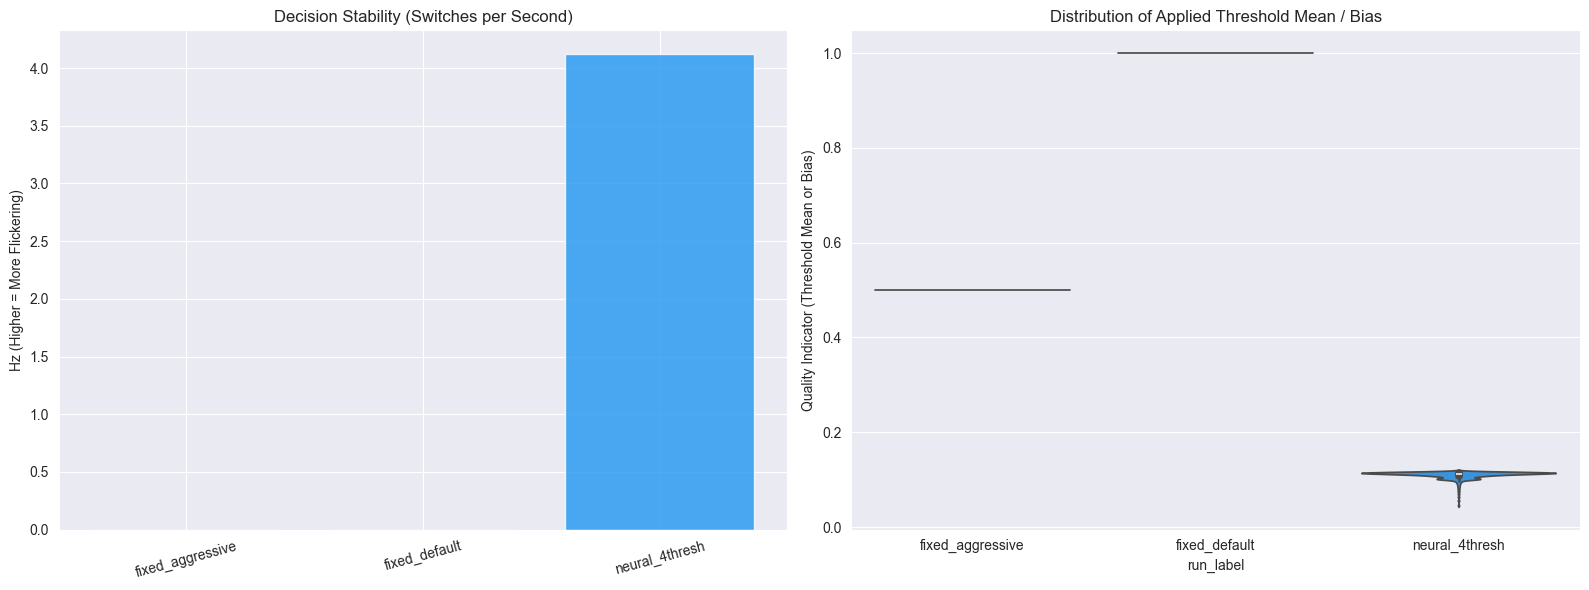

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
palette = [RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs]

# 1. Flip Rate Bar Chart
ax = axes[0]
x = np.arange(len(runs))
ax.bar(x, summary['flip_rate_hz'], color=palette, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.set_title('Decision Stability (Switches per Second)')
ax.set_ylabel('Hz (Higher = More Flickering)')

# 2. Applied Quality Distribution
# For neural we plot predicted_threshold_mean, for others lod_bias_applied
ax = axes[1]
plot_data = []
for run in runs:
    df = data[data['run_label'] == run]
    if run.startswith('neural') and 'predicted_threshold_mean' in df.columns:
        vals = df['predicted_threshold_mean']
    else:
        vals = df['lod_bias_applied']
    
    temp_df = pd.DataFrame({'run_label': run, 'quality': vals})
    plot_data.append(temp_df)

plot_df = pd.concat(plot_data)
sns.violinplot(data=plot_df, x='run_label', y='quality', palette=palette, ax=ax)
ax.set_title('Distribution of Applied Threshold Mean / Bias')
ax.set_ylabel('Quality Indicator (Threshold Mean or Bias)')

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'threshold_stability_summary.png')
plt.show()

## 4. Threshold Vector Tracking (Neural Only)

Visualizes how the 4 individual thresholds (T0-T3) evolve over time.

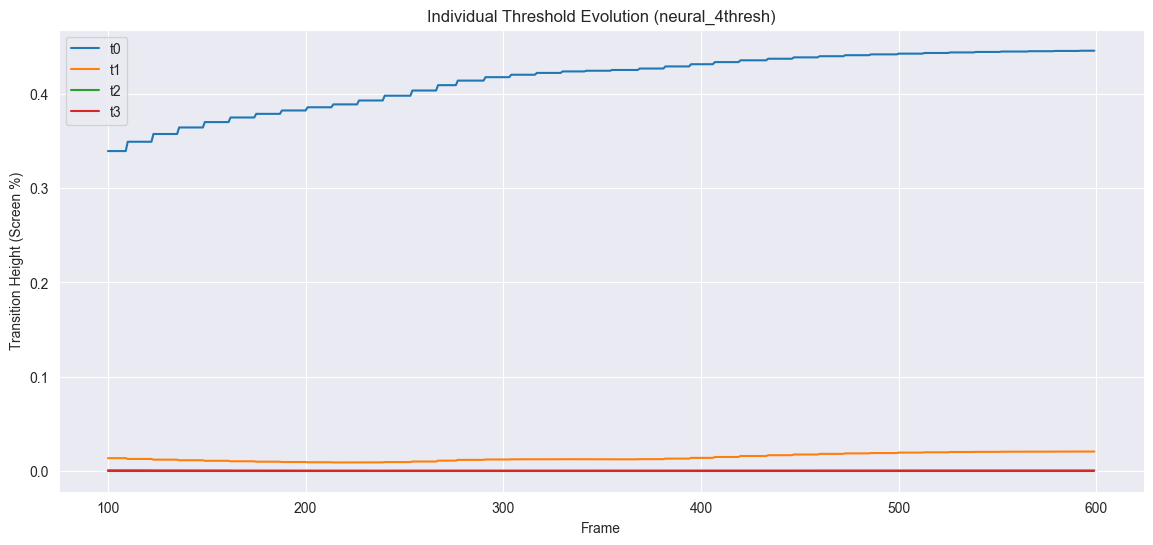

In [8]:
neural_runs = [r for r in runs if r.startswith('neural')]
if neural_runs:
    target_run = neural_runs[0]
    df_n = data[data['run_label'] == target_run].iloc[100:600] # Take a slice for clarity
    
    plt.figure(figsize=(14, 6))
    t_cols = ['predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3']
    
    for col in t_cols:
        if col in df_n.columns:
            plt.plot(df_n['frame'], df_n[col], label=col.replace('predicted_', ''))
            
    plt.title(f'Individual Threshold Evolution ({target_run})')
    plt.xlabel('Frame')
    plt.ylabel('Transition Height (Screen %)')
    plt.legend()
    plt.savefig(PLOTS_DIR / 'threshold_vector_timeseries.png')
    plt.show()
else:
    print("No neural runs found for vector tracking.")

## 5. FPS Stability Comparison

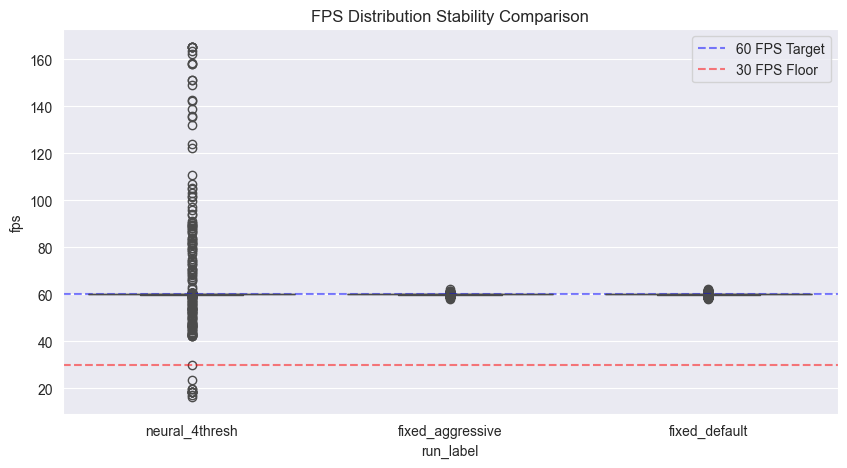

In [9]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=data, x='run_label', y='fps', palette=palette, showfliers=True)
plt.axhline(60, color='blue', linestyle='--', alpha=0.5, label='60 FPS Target')
plt.axhline(30, color='red', linestyle='--', alpha=0.5, label='30 FPS Floor')
plt.title('FPS Distribution Stability Comparison')
plt.legend()
plt.savefig(PLOTS_DIR / 'fps_comparison.png')
plt.show()

## 6. Performance Purity (CDF Plots)

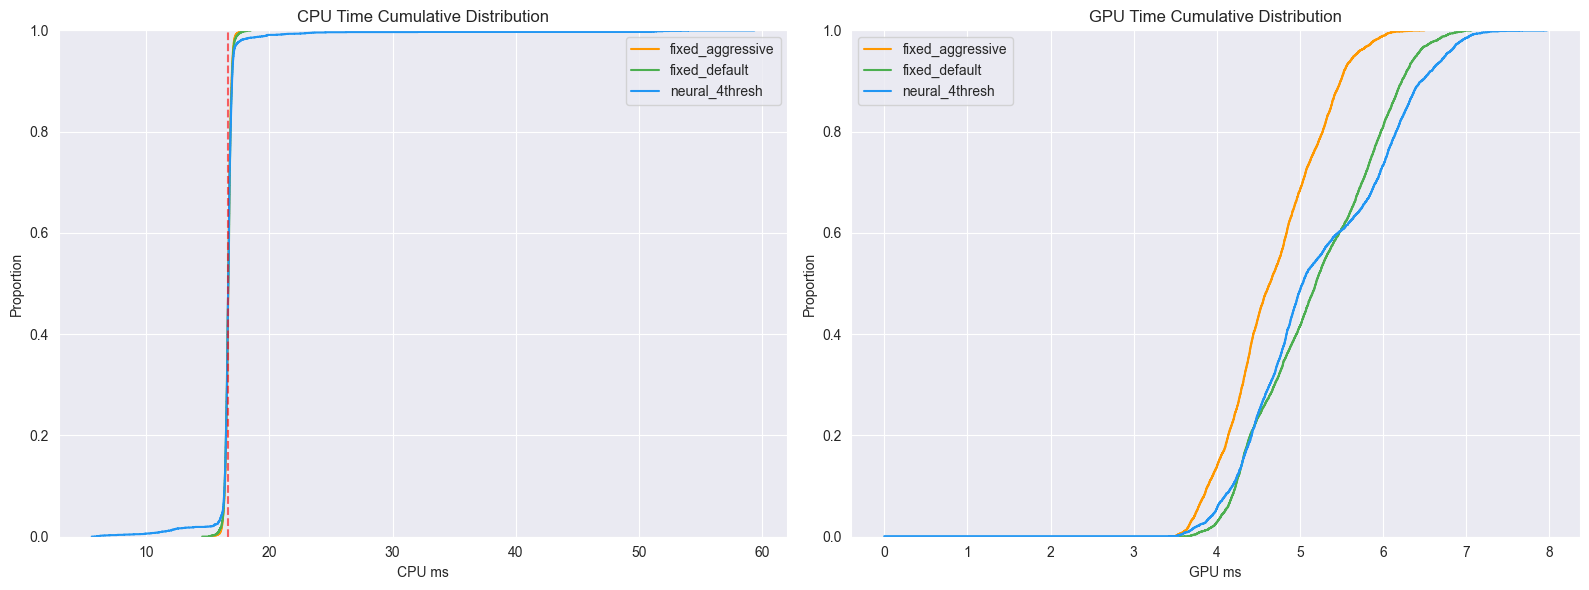

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# CPU CDF
ax = axes[0]
for run in runs:
    subset = data[data['run_label'] == run]['cpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), ax=ax)
ax.axvline(FRAME_BUDGET_MS, color='red', linestyle='--', alpha=0.6)
ax.set_title('CPU Time Cumulative Distribution')
ax.set_xlabel('CPU ms')
ax.legend()

# GPU CDF
ax = axes[1]
for run in runs:
    subset = data[data['run_label'] == run]['gpu_ms'].dropna()
    sns.ecdfplot(subset, label=run, color=RUN_COLORS.get(run, DEFAULT_COLOR), ax=ax)
ax.set_title('GPU Time Cumulative Distribution')
ax.set_xlabel('GPU ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_cdf.png')
plt.show()

## 4. CPU/GPU Frame Time Comparison

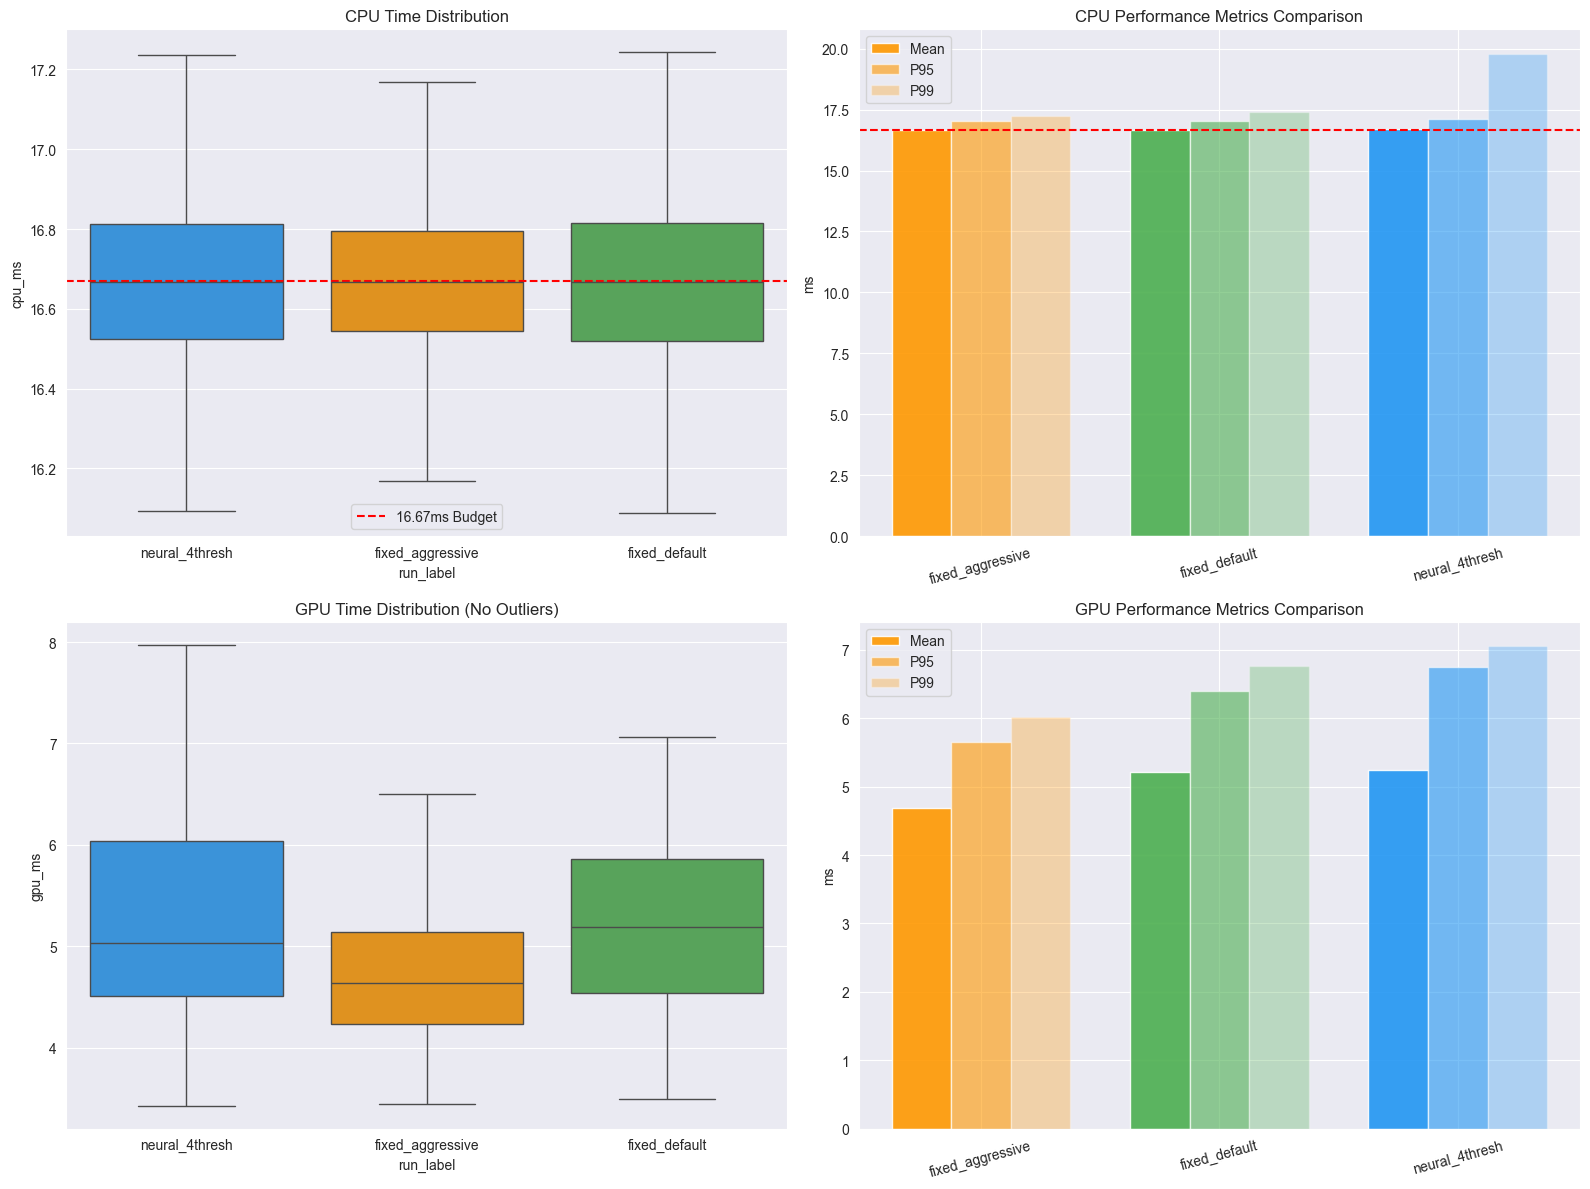

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
palette = {label: RUN_COLORS.get(label, DEFAULT_COLOR) for label in data['run_label'].unique()}

# CPU Time Boxplots
ax = axes[0, 0]
sns.boxplot(data=data, x='run_label', y='cpu_ms', palette=palette, ax=ax, showfliers=False)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--', label=f'{FRAME_BUDGET_MS}ms Budget')
ax.set_title('CPU Time Distribution')
ax.legend()

# CPU Time Comparison Bar
ax = axes[0, 1]
x = np.arange(len(runs))
w = 0.25
means = [summary.loc[r, 'mean_cpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_cpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_cpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.axhline(FRAME_BUDGET_MS, color='red', linestyle='--')
ax.set_title('CPU Performance Metrics Comparison')
ax.set_ylabel('ms')
ax.legend()

# GPU Time Boxplots
ax = axes[1, 0]
sns.boxplot(data=data, x='run_label', y='gpu_ms', palette=palette, ax=ax, showfliers=False)
ax.set_title('GPU Time Distribution (No Outliers)')

# GPU Time Comparison Bar
ax = axes[1, 1]
means = [summary.loc[r, 'mean_gpu_ms'] for r in runs]
p95s  = [summary.loc[r, 'p95_gpu_ms']  for r in runs]
p99s  = [summary.loc[r, 'p99_gpu_ms']  for r in runs]
ax.bar(x - w, means, w, label='Mean', color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.9)
ax.bar(x,     p95s,  w, label='P95',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.6)
ax.bar(x + w, p99s,  w, label='P99',  color=[RUN_COLORS.get(r, DEFAULT_COLOR) for r in runs], alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(runs, rotation=15)
ax.set_title('GPU Performance Metrics Comparison')
ax.set_ylabel('ms')
ax.legend()

plt.tight_layout()
plt.savefig(PLOTS_DIR / 'performance_comparison_matrix.png')
plt.show()

### 5. Detailed Per-Threshold Horizon Analysis


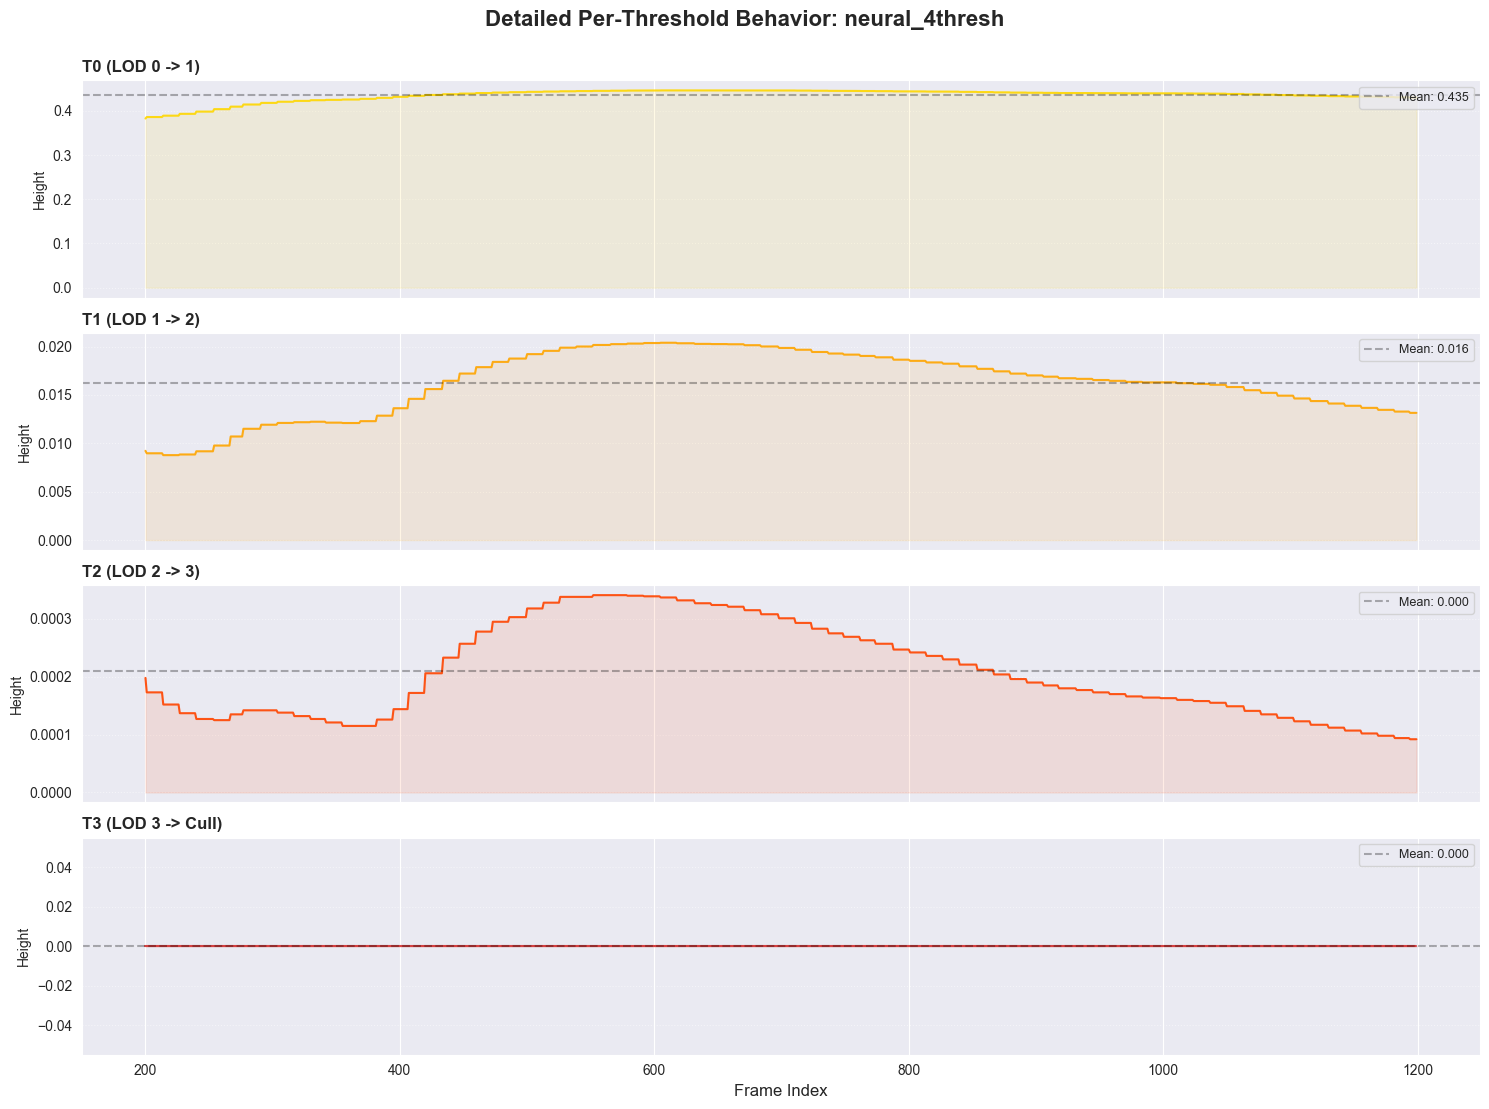

In [12]:
import matplotlib.pyplot as plt

# 1. Filter for the Stage 3 Neural Run
neural_runs = [r for r in runs if '4thresh' in r or 'neural' in r]
if neural_runs:
    target_run = neural_runs[0]
    # Adjust slice as needed
    df_plot = data[data['run_label'] == target_run].iloc[200:1200] 
    
    t_cols = ['predicted_t0', 'predicted_t1', 'predicted_t2', 'predicted_t3']
    colors = ['#FFD700', '#FFA500', '#FF4500', '#D32F2F']
    titles = ['T0 (LOD 0 -> 1)', 'T1 (LOD 1 -> 2)', 'T2 (LOD 2 -> 3)', 'T3 (LOD 3 -> Cull)']

    fig, axes = plt.subplots(4, 1, figsize=(15, 12), sharex=True)

    for i, (col, color, title) in enumerate(zip(t_cols, colors, titles)):
        ax = axes[i]
        if col in df_plot.columns:
            ax.plot(df_plot['frame'], df_plot[col], color=color, linewidth=1.5, alpha=0.9)
            ax.fill_between(df_plot['frame'], df_plot[col], alpha=0.1, color=color)
            
            # Show mean line
            mean_val = df_plot[col].mean()
            ax.axhline(mean_val, color='black', linestyle='--', alpha=0.3, label=f'Mean: {mean_val:.3f}')
            
            ax.set_ylabel('Height')
            ax.set_title(title, loc='left', fontsize=12, fontweight='bold')
            ax.grid(True, axis='y', linestyle=':', alpha=0.5)
            ax.legend(loc='upper right', fontsize=9)

    plt.xlabel('Frame Index', fontsize=12)
    fig.suptitle(f'Detailed Per-Threshold Behavior: {target_run}', fontsize=16, fontweight='bold', y=0.95)
    
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(PLOTS_DIR / 'neural_threshold_subplots.png')
    plt.show()
else:
    print("Warning: No neural run found.")


### 6. Spatial Performance Path Map (X-Z Plane)

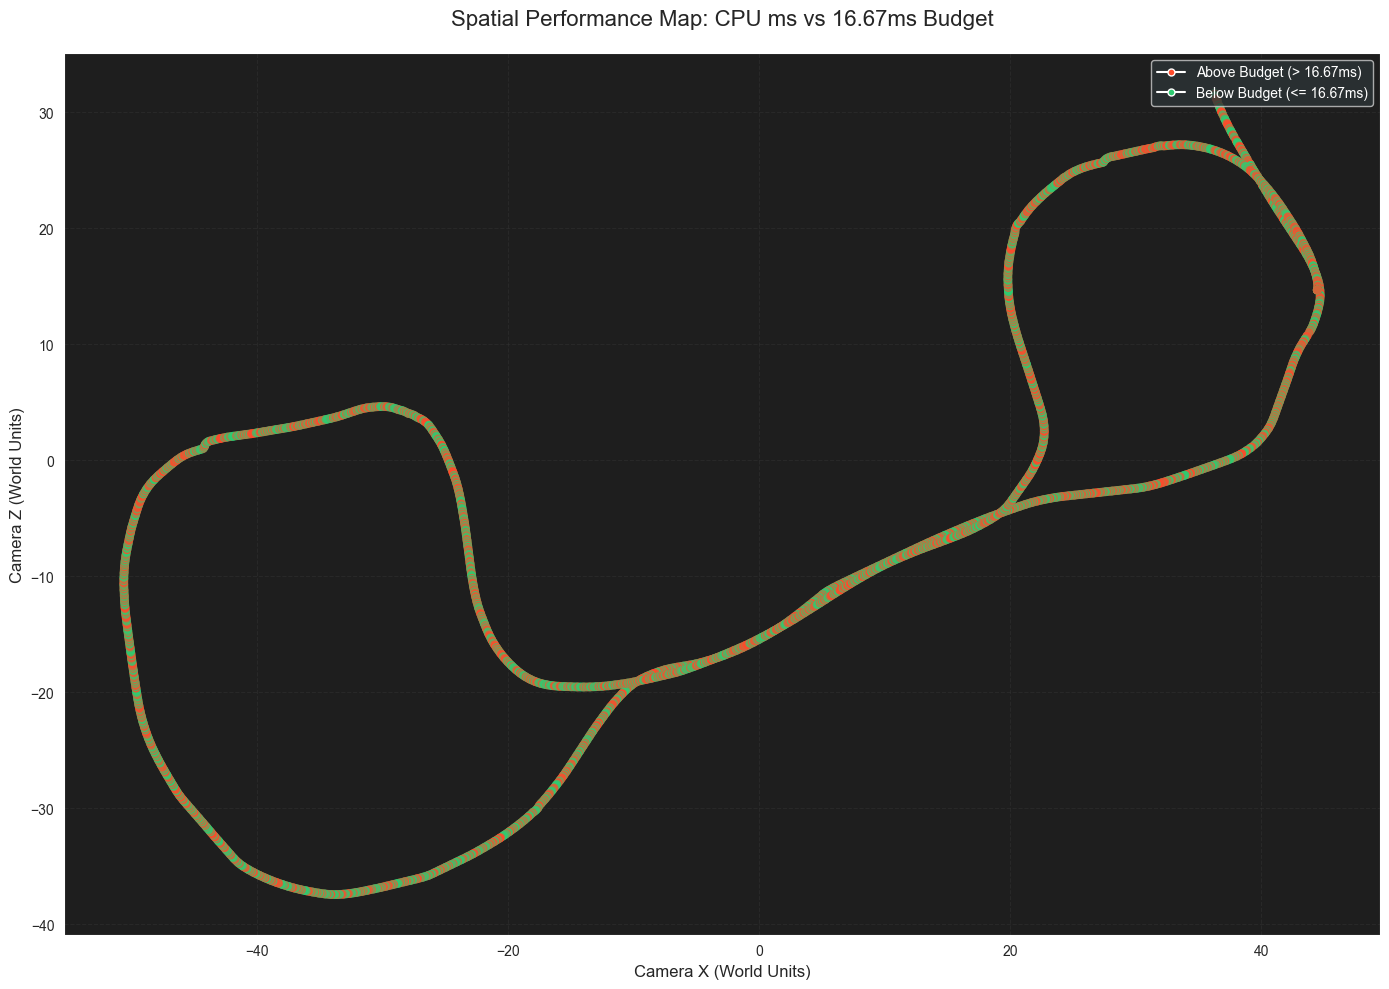

In [13]:
import matplotlib.pyplot as plt

# Define the threshold for "Expected" performance (typically your FRAME_BUDGET_MS)
TARGET_MS = FRAME_BUDGET_MS 

plt.figure(figsize=(14, 10))

# Get the data for the 'neural_4thresh' run (or whichever model you are evaluating)
plot_data = data[data['run_label'] == 'neural_4thresh']

# Logic: Red if CPU ms > TARGET_MS (Under-performing), Green if CPU ms <= TARGET_MS (Healthy)
colors = ['#FF4B2B' if ms > TARGET_MS else '#2ECC71' for ms in plot_data['cpu_ms']]

# Plot the camera path as dots
sc = plt.scatter(
    plot_data['cam_pos_x'], 
    plot_data['cam_pos_z'], 
    c=colors, 
    s=40, 
    alpha=0.7, 
    edgecolors='none'
)

# Draw the path sequence with a thin subtle line
plt.plot(plot_data['cam_pos_x'], plot_data['cam_pos_z'], color='white', alpha=0.2, linewidth=1, zorder=0)

# Formatting
plt.title(f'Spatial Performance Map: CPU ms vs {TARGET_MS}ms Budget', fontsize=16, pad=20)
plt.xlabel('Camera X (World Units)', fontsize=12)
plt.ylabel('Camera Z (World Units)', fontsize=12)

# Custom Legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label=f'Above Budget (> {TARGET_MS}ms)', markerfacecolor='#FF4B2B', markersize=5),
    Line2D([0], [0], marker='o', color='w', label=f'Below Budget (<= {TARGET_MS}ms)', markerfacecolor='#2ECC71', markersize=5)
]
plt.legend(handles=legend_elements, loc='upper right', frameon=True, facecolor='#2D3436', labelcolor='white')

# Set a dark sleek background to match your workspace aesthetics
plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


### 7. Threshold Band Widths (Delta Analysis)


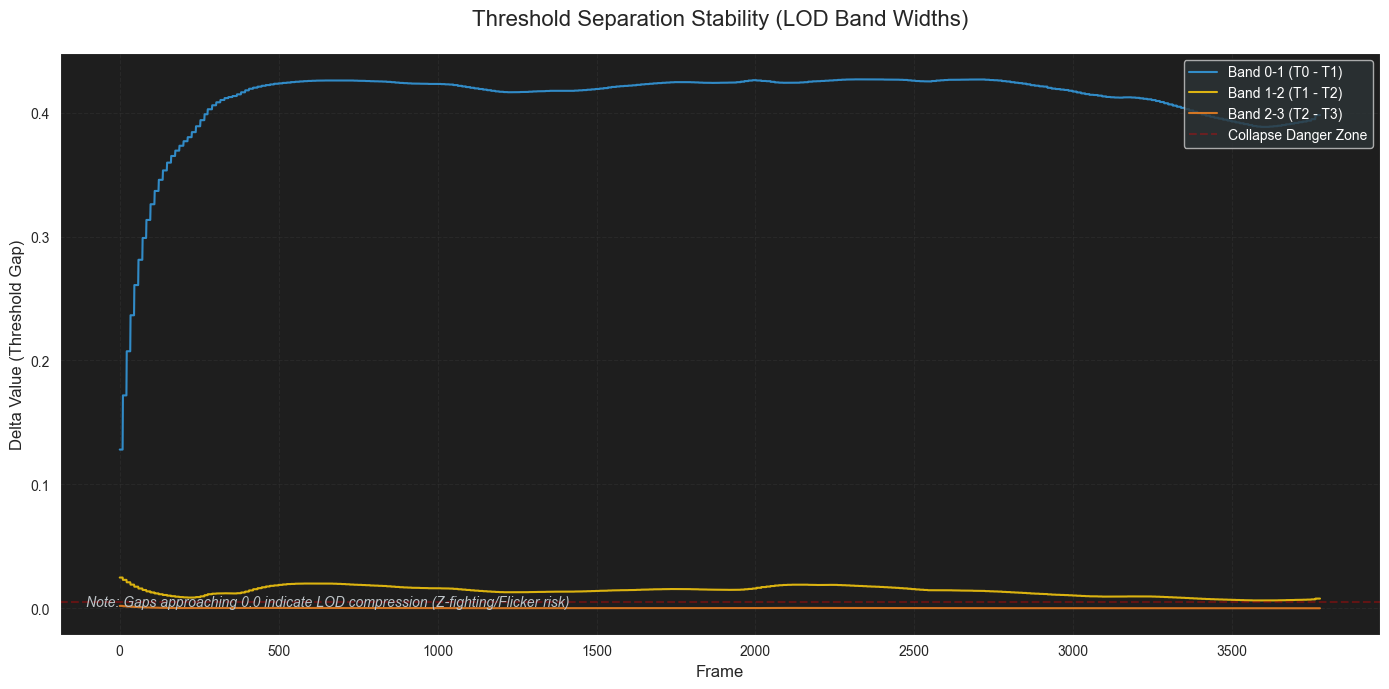

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 7))

# Get the data for the 'neural_4thresh' run
plot_data = data[data['run_label'] == 'neural_4thresh'].copy()

# Calculate the "width" of each LOD band (the delta between thresholds)
# Note: Conventionally T0 > T1 > T2 > T3
band_0_1 = plot_data['predicted_t0'] - plot_data['predicted_t1']
band_1_2 = plot_data['predicted_t1'] - plot_data['predicted_t2']
band_2_3 = plot_data['predicted_t2'] - plot_data['predicted_t3']

# Plot the deltas
plt.plot(plot_data['frame'], band_0_1, label='Band 0-1 (T0 - T1)', color='#3498DB', linewidth=1.5, alpha=0.9)
plt.plot(plot_data['frame'], band_1_2, label='Band 1-2 (T1 - T2)', color='#F1C40F', linewidth=1.5, alpha=0.9)
plt.plot(plot_data['frame'], band_2_3, label='Band 2-3 (T2 - T3)', color='#E67E22', linewidth=1.5, alpha=0.9)

# Highlight zones where LODs are "collapsing" (Delta < 0.01 or similar small value)
COLLAPSE_THRESHOLD = 0.005
plt.axhline(COLLAPSE_THRESHOLD, color='red', linestyle='--', alpha=0.3, label='Collapse Danger Zone')

# Formatting
plt.title('Threshold Separation Stability (LOD Band Widths)', fontsize=16, pad=20)
plt.xlabel('Frame', fontsize=12)
plt.ylabel('Delta Value (Threshold Gap)', fontsize=12)

# Legend and Aesthetics
plt.legend(loc='upper right', frameon=True, facecolor='#2D3436', labelcolor='white')
plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.5)

# Add a text annotation explaining the insight
plt.text(0.02, 0.05, 'Note: Gaps approaching 0.0 indicate LOD compression (Z-fighting/Flicker risk)', 
         transform=plt.gca().transAxes, color='#BDC3C7', fontsize=10, style='italic')

plt.tight_layout()

output_path = PLOTS_DIR / 'spatial_perf_map_neural_4thresh.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='#1E1E1E')
plt.show()


### 8. Velocity-Response Correlation


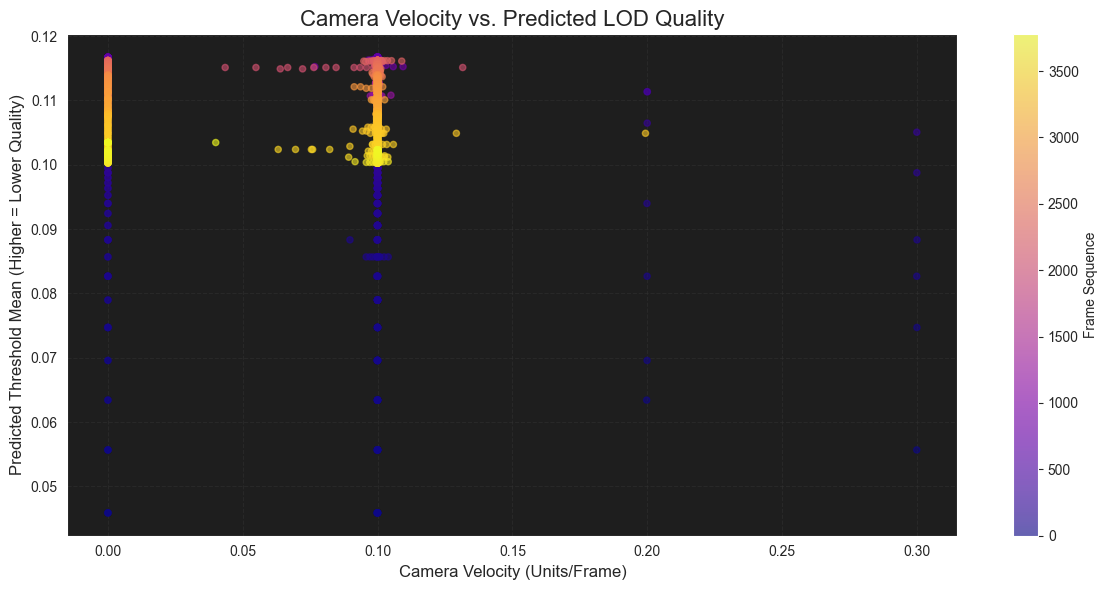

In [15]:
import numpy as np

# Select relevant data
plot_data = data[data['run_label'] == 'neural_4thresh'].copy()

# Calculate Euclidean distance between frames
dx = plot_data['cam_pos_x'].diff()
dy = plot_data['cam_pos_y'].diff()
dz = plot_data['cam_pos_z'].diff()
plot_data['velocity'] = np.sqrt(dx**2 + dy**2 + dz**2).fillna(0)

plt.figure(figsize=(12, 6))
sc = plt.scatter(plot_data['velocity'], plot_data['predicted_threshold_mean'], 
                 c=plot_data['frame'], cmap='plasma', alpha=0.6, s=20)

plt.colorbar(sc, label='Frame Sequence')
plt.title('Camera Velocity vs. Predicted LOD Quality', fontsize=16)
plt.xlabel('Camera Velocity (Units/Frame)', fontsize=12)
plt.ylabel('Predicted Threshold Mean (Higher = Lower Quality)', fontsize=12)

plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


### 9. CPU/GPU Hardware Balancing (Phase Plot)


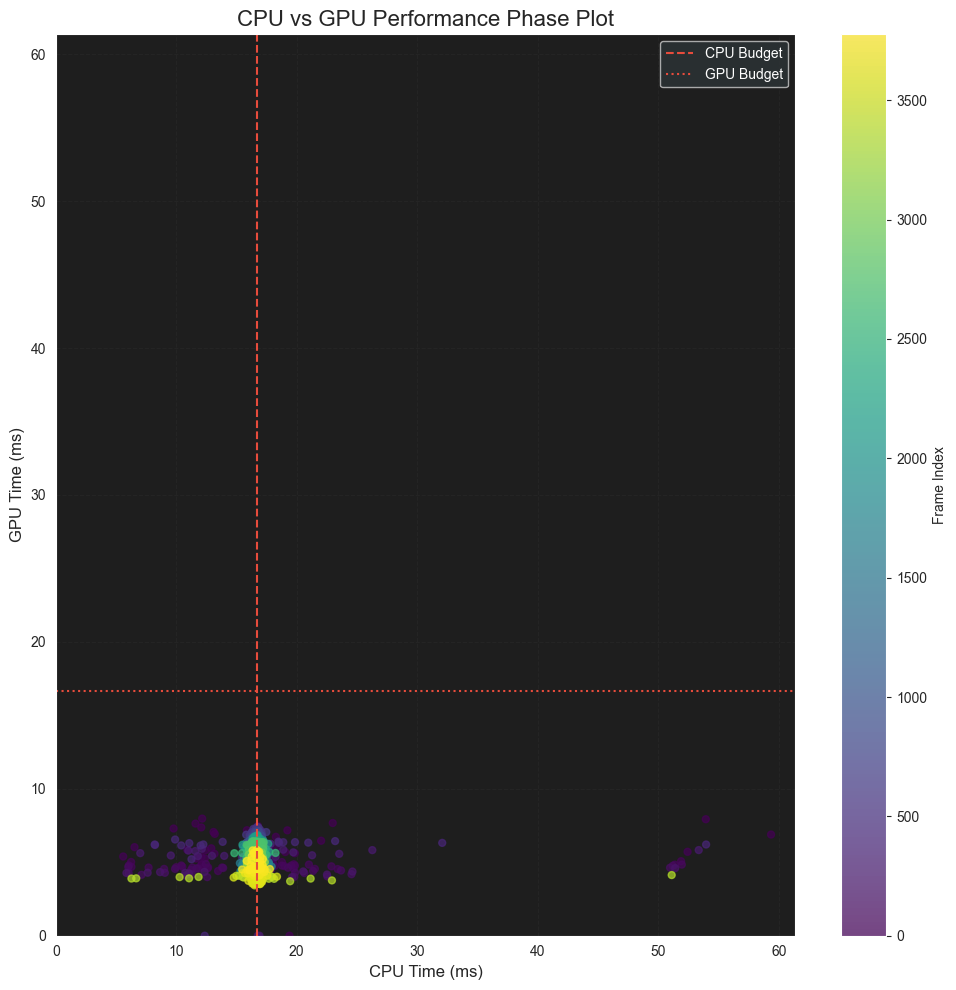

In [16]:
plot_data = data[data['run_label'] == 'neural_4thresh']

plt.figure(figsize=(10, 10))
sc = plt.scatter(plot_data['cpu_ms'], plot_data['gpu_ms'], 
                 c=plot_data['frame'], cmap='viridis', s=25, alpha=0.7)

# Draw Budget Lines
plt.axvline(FRAME_BUDGET_MS, color='#E74C3C', linestyle='--', label='CPU Budget')
plt.axhline(FRAME_BUDGET_MS, color='#E74C3C', linestyle=':', label='GPU Budget')

plt.title('CPU vs GPU Performance Phase Plot', fontsize=16)
plt.xlabel('CPU Time (ms)', fontsize=12)
plt.ylabel('GPU Time (ms)', fontsize=12)
plt.legend(facecolor='#2D3436', labelcolor='white')

plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.3)
plt.colorbar(sc, label='Frame Index')

# Equalize limits for better comparison
lim = max(plot_data['cpu_ms'].max(), plot_data['gpu_ms'].max()) + 2
plt.xlim(0, lim)
plt.ylim(0, lim)

plt.tight_layout()
output_path = PLOTS_DIR / 'cpu_vs_gpu_phase_plot_neural_4thresh.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='#1E1E1E')
plt.show()


### 10. Inference Overhead vs. Frame Budget (Stacked Area)


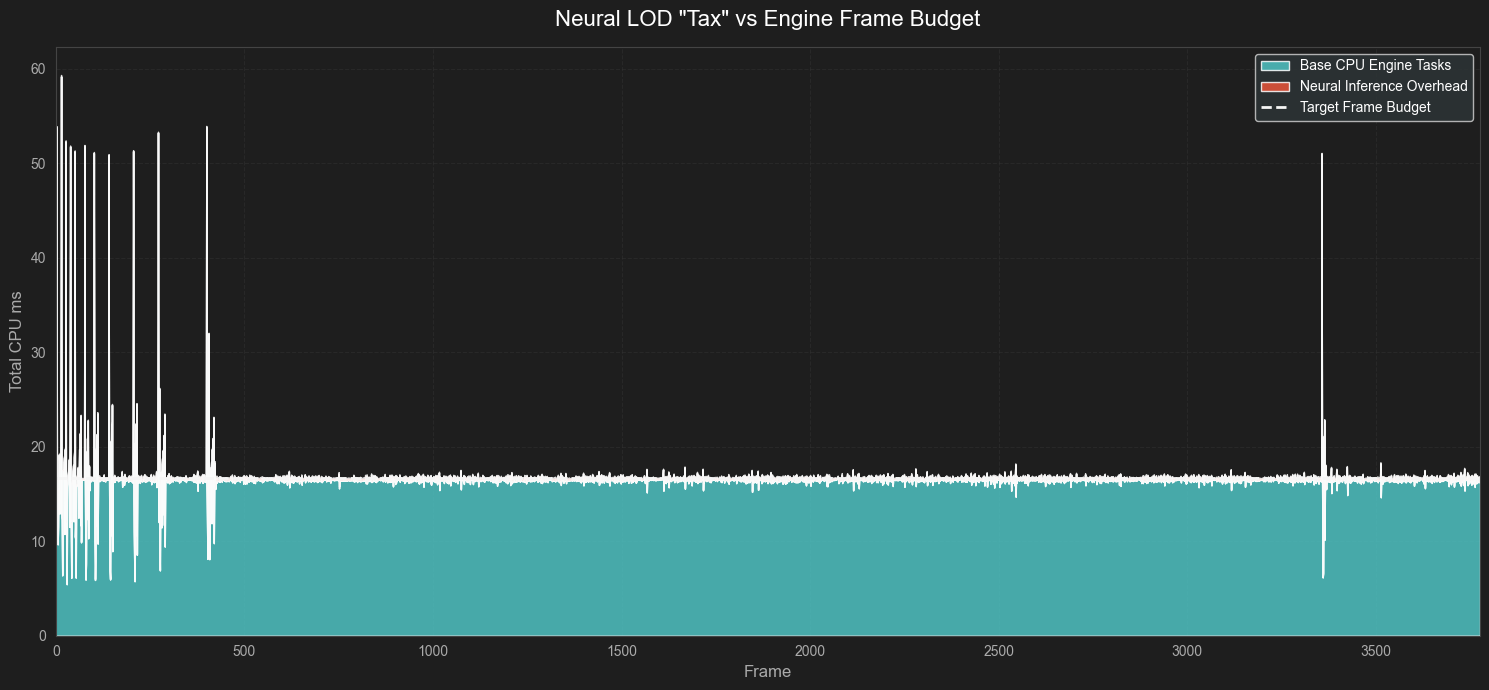

In [17]:
plot_data = data[data['run_label'] == 'neural_4thresh']

plt.figure(figsize=(15, 7))
plt.gcf().set_facecolor('#1E1E1E')

# Calculate 'Safe CPU' (CPU time excluding inference)
safe_cpu = plot_data['cpu_ms'] - plot_data['inference_duration_ms']

# ── Perceptually distinct pair on dark backgrounds ────────────────────────────
# Teal  → calm/healthy base workload (high luminance, cool hue)
# Coral → warm/alarming inference overhead (contrasting hue + luminance)
STACK_COLORS = ['#4FC3C3', '#E8543A']
# ─────────────────────────────────────────────────────────────────────────────

plt.stackplot(plot_data['frame'],
              [safe_cpu, plot_data['inference_duration_ms']],
              labels=['Base CPU Engine Tasks', 'Neural Inference Overhead'],
              colors=STACK_COLORS, alpha=0.85)

plt.axhline(FRAME_BUDGET_MS, color='#F5F5F5', linestyle='--', linewidth=2, label='Target Frame Budget')

plt.title('Neural LOD "Tax" vs Engine Frame Budget', fontsize=16, color='white', pad=15)
plt.xlabel('Frame', fontsize=12, color='#AAAAAA')
plt.ylabel('Total CPU ms', fontsize=12, color='#AAAAAA')
plt.tick_params(colors='#AAAAAA')
for spine in plt.gca().spines.values():
    spine.set_edgecolor('#444444')

plt.legend(loc='upper right', facecolor='#2D3436', labelcolor='white', framealpha=0.85)
plt.gca().set_facecolor('#1E1E1E')
plt.grid(color='#333333', linestyle='--', alpha=0.5)
plt.xlim(plot_data['frame'].min(), plot_data['frame'].max())

plt.tight_layout()

# ── Save ──────────────────────────────────────────────────────────────────────
output_path = PLOTS_DIR / 'neural_inference_tax_neural_4thresh.png'
plt.savefig(output_path, dpi=150, bbox_inches='tight', facecolor='#1E1E1E')
# ─────────────────────────────────────────────────────────────────────────────

plt.show()